# Prep

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import onnx
from pathlib import Path

BASE_DIR = Path.cwd().resolve()
YOLOV11_DIR = (BASE_DIR / ".." / "models" / "yolov11").resolve()

yolov11_csv = YOLOV11_DIR / "yolo_metrics.csv"

pd.options.display.float_format = '{:.4f}'.format 

# Metrics Compariosn

In [4]:
df = pd.read_csv(yolov11_csv)

# Standardize column names
rename_map = {
    'mAP50': 'map50', 'map@50': 'map50', 'map_50': 'map50',
    'mAP50-95': 'map50_95', 'map50-95': 'map50_95', 'mAP50_95': 'map50_95', 'map_50_95': 'map50_95',
    'Precision': 'precision', 'Recall': 'recall'
}

df.columns = [rename_map.get(c, c.lower()) for c in df.columns]

# Infer variant column if missing / inconsistent
possible_variant_cols = ['variant','model','name']

def extract_variant(val: str):
    if not isinstance(val, str):
        return None
    low = val.lower()
    # map short codes
    if 'nano' in low or low.endswith('-n') or low.endswith('n'): return 'nano'
    if 'small' in low or low.endswith('-s') or low.endswith('s'): return 'small'
    if 'medium' in low or low.endswith('-m') or low.endswith('m'): return 'medium'
    # fallback patterns
    for k,v in {'n':'nano','s':'small','m':'medium'}.items():
        if low.endswith(k):
            return v
    return None


# find a source column
source_val = None
for col in possible_variant_cols:
    if col in df.columns:
        source_val = col
        break
if source_val is None:
    # create a dummy variant sequence if absent
    df['variant'] = ['nano','small','medium'][:len(df)]
else:
    df['variant'] = df[source_val].apply(extract_variant)
    # fill any missing by position if exactly 3 rows
    if df['variant'].isna().any() and len(df) == 3:
        df.loc[df['variant'].isna(),'variant'] = ['nano','small','medium']
df['arch'] = "yolov11"

needed_cols = ['map50','map50_95','precision','recall']

for col in needed_cols:
    if col not in df.columns:
        df[col] = pd.NA

# Combine all three architectures: RF-DETR, YOLOv11, and YOLOv12
combined = pd.concat([
    df[needed_cols + ['variant', 'arch']],
], ignore_index=True)

# Build a model ID (arch-variant)
combined['model'] = combined['arch'] + '-' + combined['variant']

# Display preview
combined

,map50,map50_95,precision,recall,variant,arch,model
0,0.8800,0.6953,0.8466,0.8025,nano,yolov11,yolov11-nano
1,0.8916,0.7105,0.8484,0.8381,small,yolov11,yolov11-small
2,0.8976,0.7071,0.8640,0.8398,medium,yolov11,yolov11-medium


## Visualzation

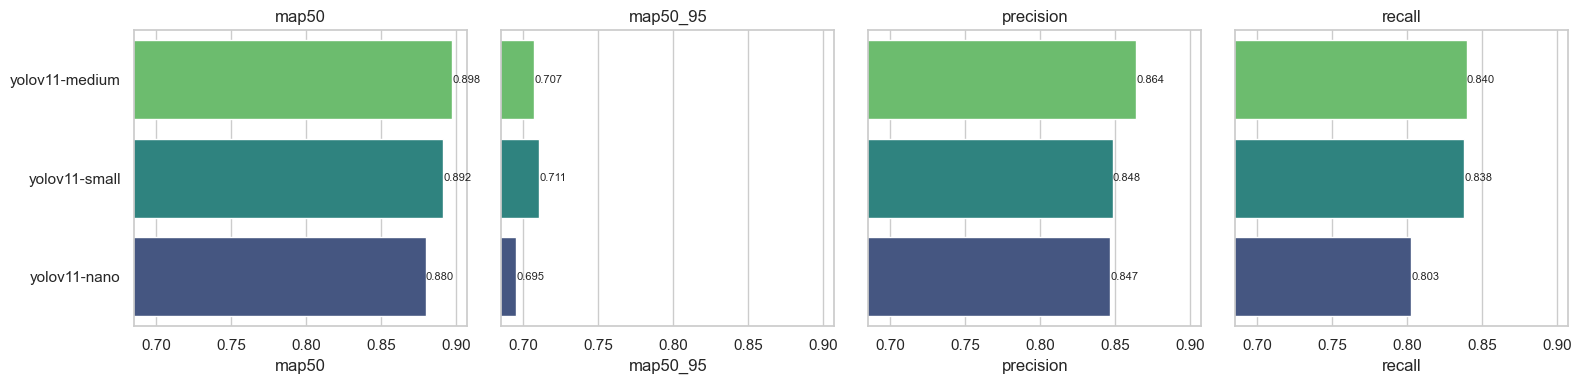

In [5]:
metrics = ['map50','map50_95','precision','recall']
plot_df = combined.melt(id_vars=['model','arch','variant'], value_vars=metrics, var_name='metric', value_name='value')

# Drop rows where all values are NA (unlikely but safe)
plot_df = plot_df.dropna(subset=['value'])

# Compute global min/max for scaling
mn, mx = plot_df['value'].min(), plot_df['value'].max()
rng = mx - mn if mx is not None else 0
# Tight y-range with small margin so similar values are distinguishable
ylim_low = max(0, mn - rng * 0.05)
ylim_high = min(1.0, mx + rng * 0.05)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 4), sharey=True)
for ax, m in zip(axes, metrics):
    sub = combined[['model', m]].dropna()
    order = sub.sort_values(m, ascending=False)['model']
    sns.barplot(data=sub, x=m, y='model', order=order, ax=ax, hue='model', dodge=False, palette='viridis')
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_title(m)
    ax.set_xlabel(m)
    ax.set_ylabel('')
    ax.set_xlim(ylim_low, ylim_high)
    # annotate bars
    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f', fontsize=8)
fig.tight_layout()
plt.show()

## Ranking

In [6]:
# Ranking with composite score 
ranking_df = combined.copy()

# Ensure numeric for map50 and map50_95
for c in ['map50','map50_95']:
    ranking_df[c] = pd.to_numeric(ranking_df[c], errors='coerce')

# Composite score: average of map50 and map50_95 when both exist, else whichever exists
ranking_df['score'] = [
    (m50 + m95) / 2.0 if pd.notna(m50) and pd.notna(m95)
    else (m95 if pd.notna(m95) else m50)
    for m50, m95 in zip(ranking_df['map50'], ranking_df['map50_95'])
]

ranking_df = ranking_df.sort_values('score', ascending=False)
ranking_df[['model','variant','arch','map50','map50_95','precision','recall','score']].reset_index(drop=True)

,model,variant,arch,map50,map50_95,precision,recall,score
0,yolov11-medium,medium,yolov11,0.8976,0.7071,0.8640,0.8398,0.8024
1,yolov11-small,small,yolov11,0.8916,0.7105,0.8484,0.8381,0.8010
2,yolov11-nano,nano,yolov11,0.8800,0.6953,0.8466,0.8025,0.7876


# Inference Time Comparison

In [11]:
ONNX_CSV = (BASE_DIR / ".." / "onnx_benchmark_results_20260308_021800.csv").resolve()
print(ONNX_CSV)

onnx_df = pd.read_csv(ONNX_CSV)
print(onnx_df)

D:\Workspace\Repository\thesis\research\object-detection-engine\onnx_benchmark_results_20260308_021800.csv
        Model Input_Size    Phase    Mean  Median     P90     P95     Min  \
0   YOLOv11-n    416x416    T_pre  0.9538  0.9280  1.0593  1.0893  0.8447   
1   YOLOv11-n    416x416  T_infer  9.5599  9.3561 11.2834 11.5381  7.9597   
2   YOLOv11-n    416x416   T_post  0.1504  0.1414  0.1750  0.1816  0.1330   
3   YOLOv11-n    416x416  T_total 10.6641 10.4726 12.4733 12.6892  9.0136   
4   YOLOv11-s    416x416    T_pre  0.9437  0.9281  1.0186  1.0509  0.8587   
5   YOLOv11-s    416x416  T_infer 20.8190 20.1911 25.3956 26.2445 17.6380   
6   YOLOv11-s    416x416   T_post  0.1507  0.1414  0.1796  0.2023  0.1353   
7   YOLOv11-s    416x416  T_total 21.9134 21.3489 26.4978 27.3272 18.6929   
8   YOLOv11-m    416x416    T_pre  0.9598  0.9411  1.0375  1.0732  0.8681   
9   YOLOv11-m    416x416  T_infer 55.1258 54.7388 64.0529 66.0488 45.7347   
10  YOLOv11-m    416x416   T_post  0.1522  0.1

In [12]:

csv_files = sorted((BASE_DIR / "..").resolve().glob("onnx_benchmark_results_*.csv"))
print(f"Found {len(csv_files)} benchmark run(s):")
for f in csv_files:
    print(f"  {f.name}")

all_runs = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

numeric_cols = ["Mean", "Median", "P90", "P95", "Min", "Max"]
latency_df = (
    all_runs
    .groupby(["Model", "Input_Size", "Phase"], sort=False)[numeric_cols]
    .mean()
    .reset_index()
)

def _parse_model(name: str):
    parts = name.lower().split("-")
    arch = parts[0]
    suffix = parts[-1] if len(parts) > 1 else ""
    variant_map = {"n": "nano", "s": "small", "m": "medium"}
    variant = variant_map.get(suffix, suffix)
    return arch, variant

latency_df[["arch", "variant"]] = pd.DataFrame(
    latency_df["Model"].map(_parse_model).tolist(), index=latency_df.index
)

latency_df = latency_df[latency_df["Phase"] == "T_total"].reset_index(drop=True)
latency_df


Found 1 benchmark run(s):
  onnx_benchmark_results_20260308_021800.csv


,Model,Input_Size,Phase,Mean,Median,P90,P95,Min,Max,arch,variant
0,YOLOv11-n,416x416,T_total,10.6641,10.4726,12.4733,12.6892,9.0136,14.4158,yolov11,nano
1,YOLOv11-s,416x416,T_total,21.9134,21.3489,26.4978,27.3272,18.6929,29.0453,yolov11,small
2,YOLOv11-m,416x416,T_total,56.2377,55.8256,65.2440,67.1855,46.7946,73.3533,yolov11,medium


## Visualization

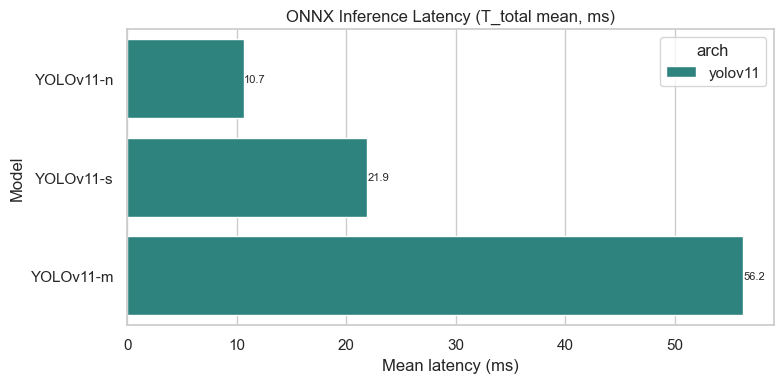

In [13]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=latency_df,
    x="Mean",
    y="Model",
    hue="arch",
    dodge=False,
    palette="viridis"
)

ax.set_title("ONNX Inference Latency (T_total mean, ms)")
ax.set_xlabel("Mean latency (ms)")
ax.set_ylabel("Model")
# Annotate bars with exact values
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", fontsize=8)

plt.tight_layout()
plt.show()

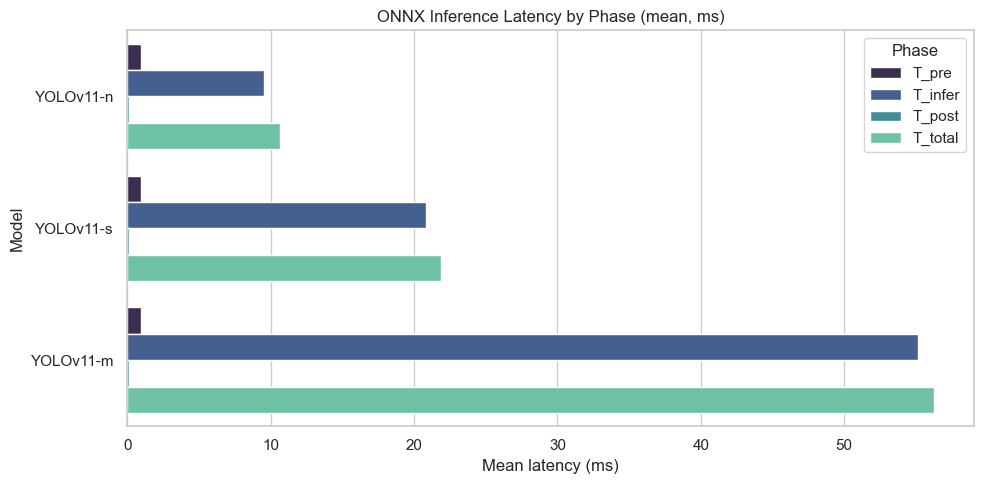

In [14]:
plt.figure(figsize=(10, 5))
phase_df = onnx_df.copy()
sns.barplot(
    data=phase_df,
    x="Mean",
    y="Model",
    hue="Phase",
    palette="mako"
)
plt.title("ONNX Inference Latency by Phase (mean, ms)")
plt.xlabel("Mean latency (ms)")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## Ranking

In [15]:
# Rank models by mean total latency (fastest first)
latency_rank = latency_df.copy()
latency_rank["rank"] = latency_rank["Mean"].rank(method="min", ascending=True).astype(int)
latency_rank = latency_rank.sort_values("Mean", ascending=True)

latency_rank[[
    "rank", "Model", "arch", "variant", "Input_Size",
    "Mean", "P90", "P95"
]].reset_index(drop=True)

,rank,Model,arch,variant,Input_Size,Mean,P90,P95
0,1,YOLOv11-n,yolov11,nano,416x416,10.6641,12.4733,12.6892
1,2,YOLOv11-s,yolov11,small,416x416,21.9134,26.4978,27.3272
2,3,YOLOv11-m,yolov11,medium,416x416,56.2377,65.2440,67.1855
